# Chip vs Pitch Feature Exploration

Goal: figure out which features separate chips from pitches (and eventually putts).

Files:
- `10long chips.fit` — 10 long chip shots
- `10x45mpitch.fit` — 10x 45m pitch shots

Known so far: `peak_mag` separates pitches (max 5969mg) from chips (max 1885mg), but chips overlap putts. We want to see if `max_jerk` and `std_mag` give us a cleaner chip signature.

In [1]:
import fitparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

In [2]:
DEV_FIELDS = ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']

def load(fname):
    fit = fitparse.FitFile(fname)
    rows = [{f.name: f.value for f in r.fields} for r in fit.get_messages('record')]
    df = pd.DataFrame(rows)
    df = df.dropna(subset=['peak_mag']).reset_index(drop=True)
    df['t'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
    return df

chips = load('10long chips.fit')
pitches = load('10x45mpitch.fit')
print(f'Chips: {len(chips)} records, {chips["t"].iloc[-1]:.0f}s')
print(f'Pitches: {len(pitches)} records, {pitches["t"].iloc[-1]:.0f}s')
print()
print('Available dev fields:', [c for c in DEV_FIELDS if c in chips.columns])

Chips: 42 records, 41s
Pitches: 379 records, 378s

Available dev fields: ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']


## 1. Are jerk and std_mag actually populated?

Last session we noticed `parse_fit.py` only listed 4 dev fields. Let's check if `max_jerk`, `std_mag`, `min_mag`, `mean_mag` are present in the new files.

In [3]:
for name, df in [('chips', chips), ('pitches', pitches)]:
    print(f'=== {name} ===')
    for f in DEV_FIELDS:
        if f in df.columns:
            n_valid = df[f].notna().sum()
            if n_valid:
                print(f'  {f}: {n_valid}/{len(df)} valid, range [{df[f].min():.0f}, {df[f].max():.0f}], mean={df[f].mean():.0f}')
            else:
                print(f'  {f}: ALL NULL')
        else:
            print(f'  {f}: MISSING from columns')
    print()

=== chips ===
  peak_mag: 42/42 valid, range [1048, 1885], mean=1337
  min_mag: 42/42 valid, range [702, 991], mean=877
  mean_mag: 42/42 valid, range [959, 1193], mean=1049
  std_mag: 42/42 valid, range [23, 303], mean=116
  max_jerk: 42/42 valid, range [46, 1077], mean=301
  peak_x: 42/42 valid, range [828, 1522], mean=1136
  peak_y: 42/42 valid, range [170, 1251], mean=380
  peak_z: 42/42 valid, range [479, 1519], mean=827

=== pitches ===
  peak_mag: 379/379 valid, range [997, 5969], mean=1343
  min_mag: 379/379 valid, range [196, 1020], mean=857
  mean_mag: 379/379 valid, range [871, 2080], mean=1052
  std_mag: 379/379 valid, range [3, 1560], mean=131
  max_jerk: 379/379 valid, range [8, 4440], mean=272
  peak_x: 379/379 valid, range [96, 4428], mean=1013
  peak_y: 379/379 valid, range [29, 2048], mean=514
  peak_z: 379/379 valid, range [127, 5570], mean=709



## 2. Time-series view of all features

Plotting features: ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']


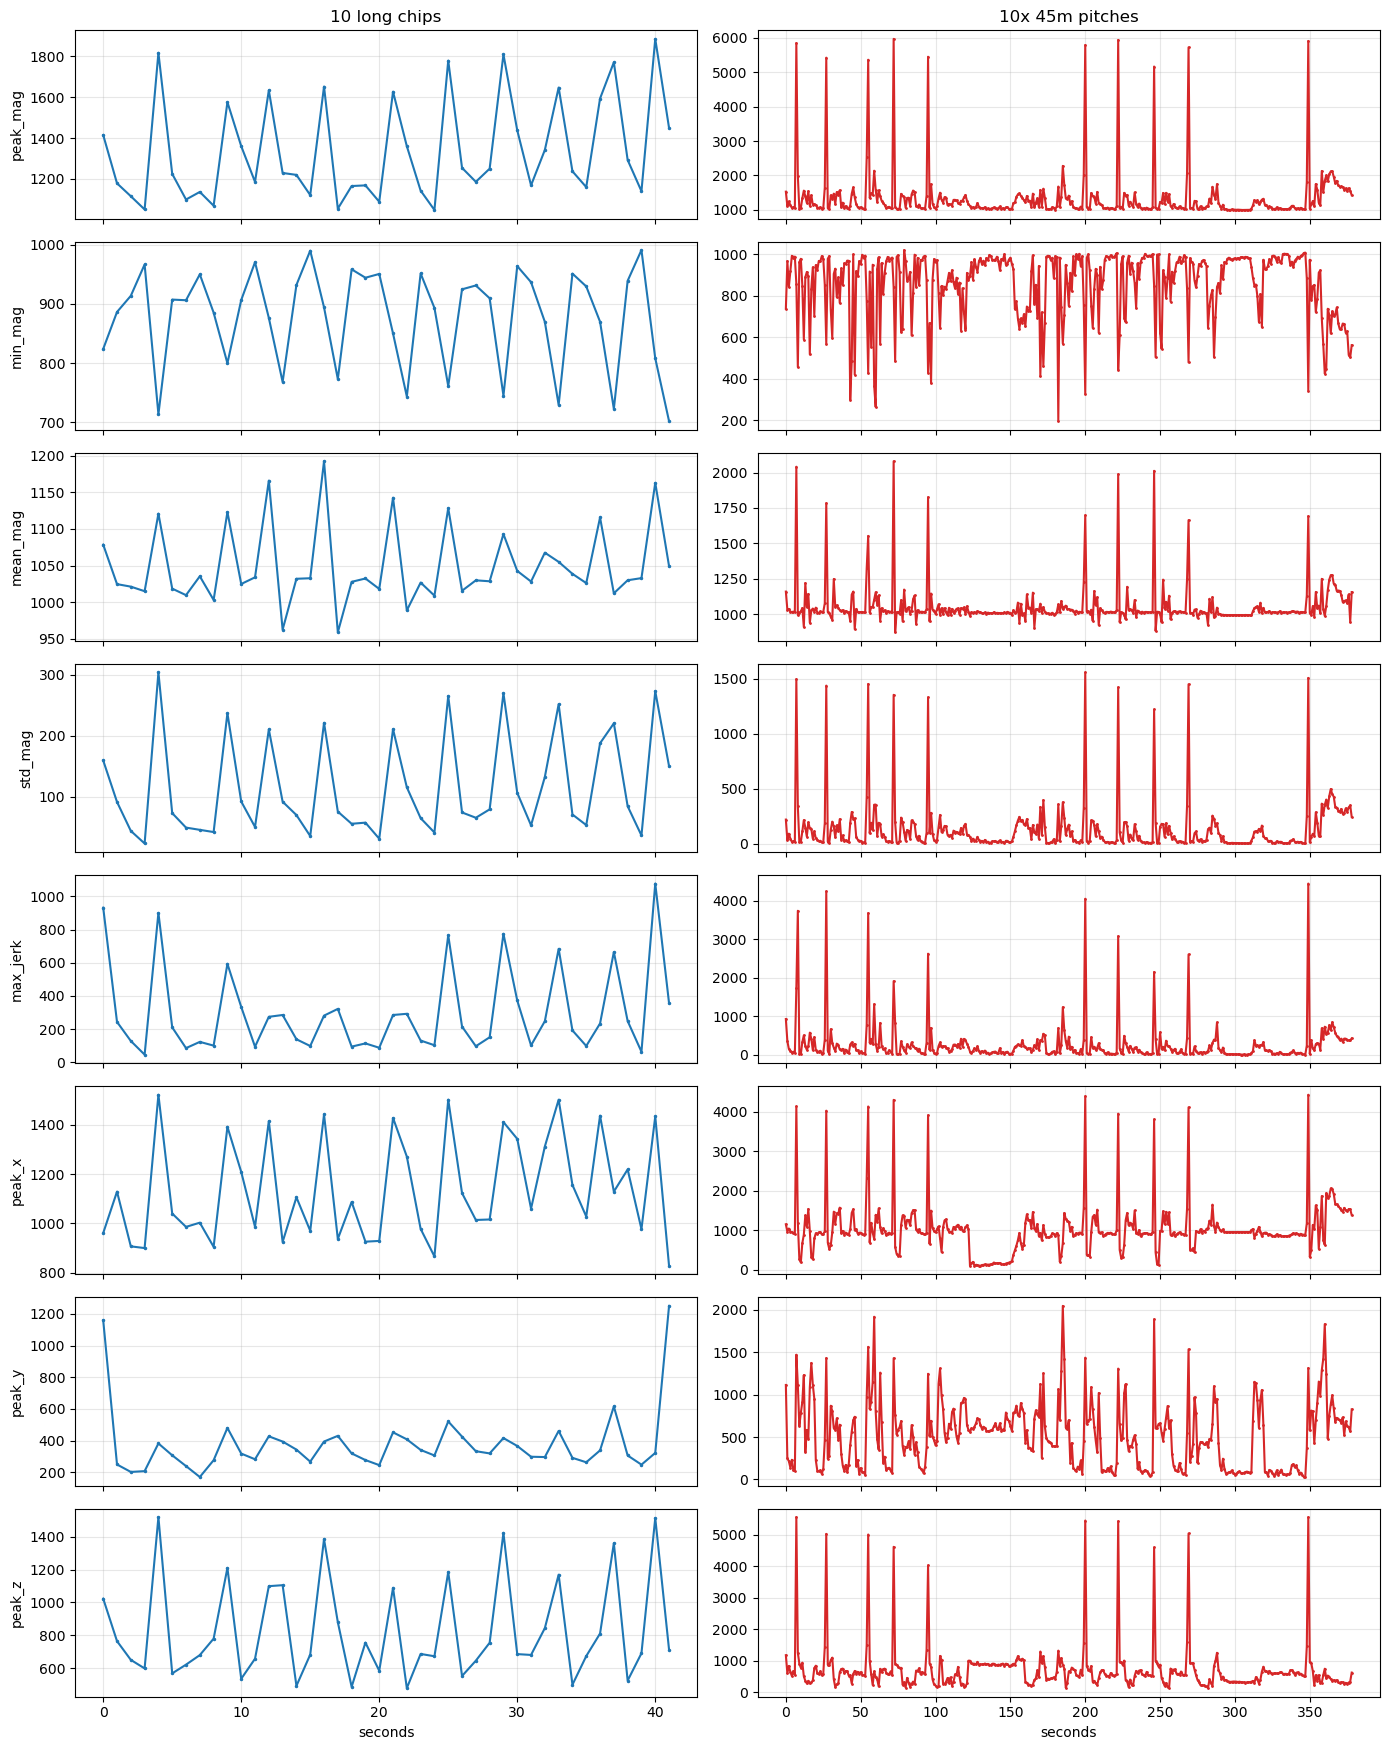

In [4]:
feature_cols = [c for c in DEV_FIELDS if c in chips.columns and chips[c].notna().any()]
print('Plotting features:', feature_cols)

fig, axes = plt.subplots(len(feature_cols), 2, figsize=(14, 2.2 * len(feature_cols)), sharex='col')
for i, feat in enumerate(feature_cols):
    axes[i, 0].plot(chips['t'], chips[feat], color='C0', marker='.', markersize=3)
    axes[i, 0].set_ylabel(feat)
    axes[i, 0].grid(alpha=0.3)
    axes[i, 1].plot(pitches['t'], pitches[feat], color='C3', marker='.', markersize=2)
    axes[i, 1].grid(alpha=0.3)
axes[0, 0].set_title('10 long chips')
axes[0, 1].set_title('10x 45m pitches')
axes[-1, 0].set_xlabel('seconds')
axes[-1, 1].set_xlabel('seconds')
plt.tight_layout()
plt.show()

## 3. Stroke segmentation using rising-edge logic

Use a per-shot-type threshold and detect rising edges (records that cross from below to above the threshold). For each detected stroke, extract a window of N seconds and aggregate features.

In [5]:
def segment_strokes(df, threshold, window_before=1, window_after=2):
    """Find rising edges where peak_mag crosses threshold; return list of (center_idx, window_df)."""
    above = df['peak_mag'].values > threshold
    edges = []
    for i in range(len(above)):
        if above[i] and (i == 0 or not above[i-1]):
            start = max(0, i - window_before)
            end = min(len(df), i + window_after + 1)
            edges.append((i, df.iloc[start:end].copy()))
    return edges

chip_strokes = segment_strokes(chips, threshold=1500)
pitch_strokes = segment_strokes(pitches, threshold=3000)
print(f'Chips detected: {len(chip_strokes)} (expected 10)')
print(f'Pitches detected: {len(pitch_strokes)} (expected 10)')

Chips detected: 10 (expected 10)
Pitches detected: 10 (expected 10)


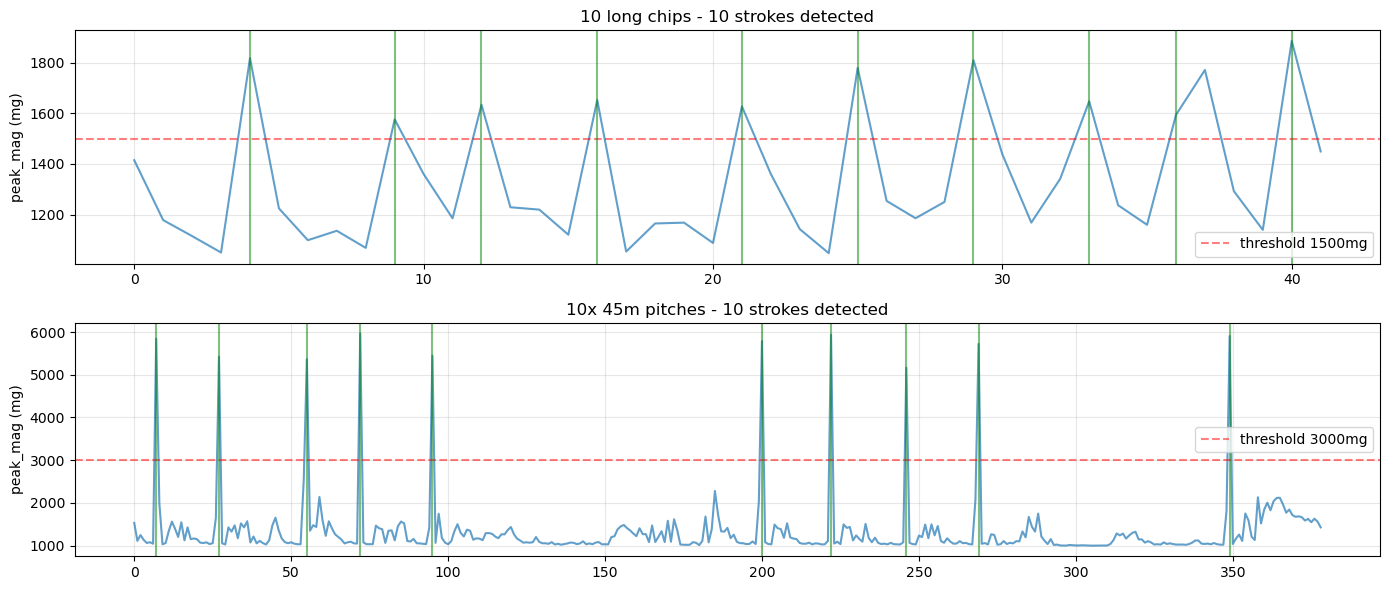

In [6]:
# Visualise detected strokes on the time-series
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
for ax, (df, strokes, title, thr) in zip(axes, [
    (chips, chip_strokes, '10 long chips', 1500),
    (pitches, pitch_strokes, '10x 45m pitches', 3000),
]):
    ax.plot(df['t'], df['peak_mag'], color='C0', alpha=0.7)
    ax.axhline(thr, color='red', ls='--', alpha=0.5, label=f'threshold {thr}mg')
    for idx, _ in strokes:
        ax.axvline(df['t'].iloc[idx], color='green', alpha=0.5)
    ax.set_title(f'{title} - {len(strokes)} strokes detected')
    ax.set_ylabel('peak_mag (mg)')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Per-stroke feature aggregation

For each detected stroke, compute aggregated features over its window.

In [7]:
def stroke_features(window):
    feats = {}
    for col in ['peak_mag', 'peak_x', 'peak_y', 'peak_z', 'max_jerk', 'std_mag', 'mean_mag']:
        if col in window.columns and window[col].notna().any():
            feats[f'{col}_max'] = window[col].max()
            feats[f'{col}_mean'] = window[col].mean()
    return feats

rows = []
for idx, w in chip_strokes:
    f = stroke_features(w)
    f['label'] = 'chip'
    rows.append(f)
for idx, w in pitch_strokes:
    f = stroke_features(w)
    f['label'] = 'pitch'
    rows.append(f)

feat_df = pd.DataFrame(rows)
feat_df

,peak_mag_max,peak_mag_mean,peak_x_max,peak_x_mean,peak_y_max,peak_y_mean,peak_z_max,peak_z_mean,max_jerk_max,max_jerk_mean,std_mag_max,std_mag_mean,mean_mag_max,mean_mag_mean,label
0,1817.281738,1297.837616,1522.0,1112.000000,382.0,283.75,1519.0,827.250000,900.650391,310.921738,303.451080,112.276951,1121.010986,1040.945251,chip
1,1575.726196,1297.511078,1392.0,1123.000000,480.0,339.00,1210.0,796.000000,593.794800,280.739136,236.692169,105.307896,1123.217529,1046.196289,chip
2,1633.530273,1316.917419,1415.0,1108.000000,427.0,361.50,1105.0,838.750000,285.328796,198.290451,210.075714,105.531771,1166.179321,1048.544266,chip
3,1651.900146,1247.993164,1442.0,1109.000000,430.0,352.50,1385.0,858.750000,322.057983,199.248459,220.927795,96.895830,1192.720825,1052.912674,chip
4,1626.933960,1304.467987,1428.0,1151.500000,452.0,361.50,1089.0,710.000000,292.515503,199.312943,210.463852,105.438719,1142.777344,1044.007645,chip
5,1778.973022,1316.672852,1502.0,1126.250000,521.0,396.25,1185.0,764.250000,765.649475,295.408752,264.933807,111.446359,1128.551636,1045.636520,chip
6,1809.328613,1416.459259,1411.0,1207.500000,416.0,349.75,1423.0,886.250000,774.531006,350.135071,269.435883,126.999481,1093.046021,1048.058319,chip
7,1647.249878,1346.442902,1502.0,1249.500000,461.0,327.75,1169.0,796.750000,684.057251,305.754700,251.450531,126.991906,1067.599121,1046.817047,chip
8,1770.848633,1454.226257,1437.0,1203.250000,616.0,380.75,1360.0,842.500000,664.933105,311.629089,220.024094,136.316413,1115.741089,1045.899902,chip
9,1885.377686,1491.472209,1434.0,1079.666667,1251.0,607.00,1513.0,972.333333,1077.338135,499.264201,272.614838,153.010778,1163.134277,1081.688558,chip


In [8]:
# Per-feature separation: how well does each feature split chip from pitch?
from scipy import stats

numeric_cols = [c for c in feat_df.columns if c != 'label']
rows = []
for col in numeric_cols:
    chip_vals = feat_df[feat_df['label'] == 'chip'][col].dropna()
    pitch_vals = feat_df[feat_df['label'] == 'pitch'][col].dropna()
    if len(chip_vals) and len(pitch_vals):
        # Cohen's d effect size
        pooled = np.sqrt((chip_vals.var() + pitch_vals.var()) / 2)
        d = abs(chip_vals.mean() - pitch_vals.mean()) / pooled if pooled > 0 else 0
        rows.append({
            'feature': col,
            'chip_mean': chip_vals.mean(),
            'pitch_mean': pitch_vals.mean(),
            'cohens_d': d,
        })
sep = pd.DataFrame(rows).sort_values('cohens_d', ascending=False)
sep

,feature,chip_mean,pitch_mean,cohens_d
0,peak_mag_max,1719.715015,5657.604492,18.438101
2,peak_x_max,1448.500000,4117.300000,17.898770
10,std_mag_max,246.006976,1425.206592,16.187886
13,mean_mag_mean,1050.070647,1235.039557,13.512625
6,peak_z_max,1295.800000,5039.300000,10.023538
7,peak_z_mean,829.283333,1985.950000,8.721842
11,std_mag_mean,118.021610,442.872242,8.300494
1,peak_mag_mean,1349.000074,2395.137228,8.175906
12,mean_mag_max,1131.397815,1833.340112,5.258301
4,peak_y_max,543.600000,1463.300000,4.141396


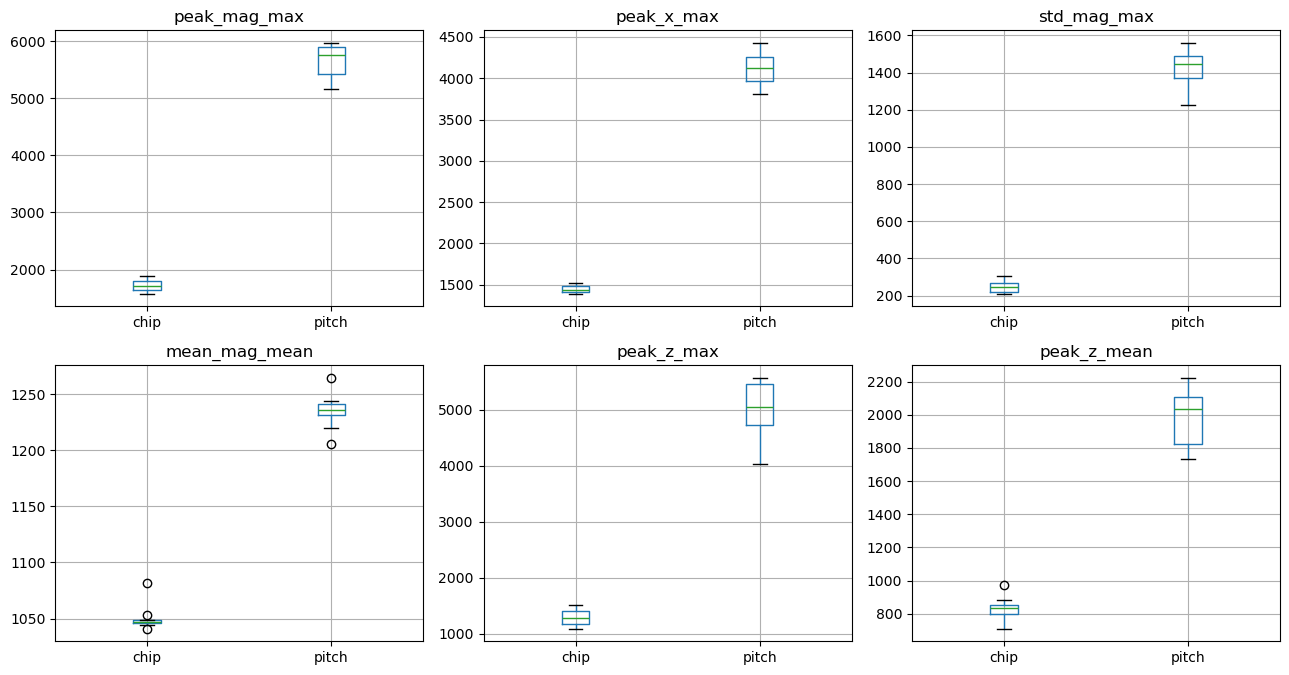

In [9]:
# Box plots of top features
top_feats = sep['feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, top_feats):
    feat_df.boxplot(column=feat, by='label', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Notes / next session

- If `max_jerk` or `std_mag` are NULL in these files, the SwingLogger Monkey C app may not be writing them — check `source/SwingLoggerView.mc` for the FitContributor `setData` calls.
- Tomorrow: collect more chip + putt data, then re-run this notebook with the chip-vs-putt comparison added.
- Once chip features look separable, fold the new stroke segmenter into `analysis_v3.ipynb` and re-train the unified classifier.